<h2 style="text-align:center;color:plum;">Task 3: Fraud Detection</h2>

<h3 style="color:skyblue;">Step 1:Load and import the dataset</h3>

In this step,we load the dataset using Pandas and check its structure,columns,datatype and missing values.We also check the number of fraudulent and normal transactions.

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



 Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null

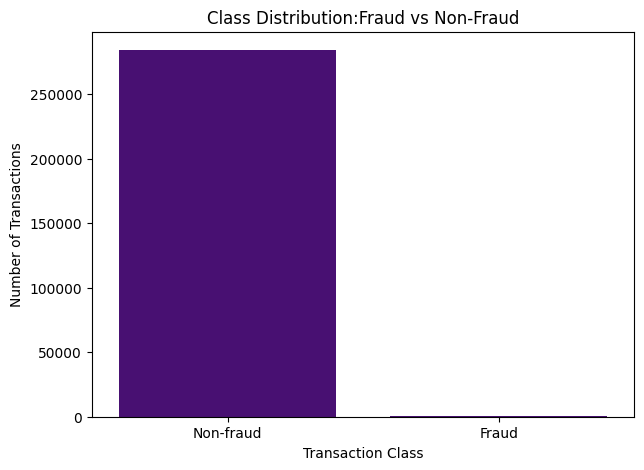

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("creditcard/creditcard.csv")
print("Dataset shape:",df.shape)
display(df.head())
print("\n Column Names:")
print(df.columns.tolist())
print("\nDataset Information:")
df.info()
print("\nMissing Value")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df["Class"].value_counts())
total_transactions=len(df)
fraud_transactions=(df["Class"]==1).sum()
normal_transactions=(df["Class"]==0).sum()
fraud_percentage=(fraud_transactions/total_transactions)*100
normal_percentage=(normal_transactions/total_transactions)*100
print("\n Total Transactions:",total_transactions)
print("Normal Transactions:",normal_transactions)
print("Fraud Transactions:",fraud_transactions)
print(f"\nNormal Transaction:{normal_percentage:4f}%")
print(f"\nFraudulent Transaction:{fraud_percentage:4f}%")
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Class",color="indigo")
plt.title("Class Distribution:Fraud vs Non-Fraud")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0,1],["Non-fraud","Fraud"])
plt.show()

<h3 style="color:skyblue;">Step 2 : Analyse class imbalance</h3>

In this step,we check the number of normal and fraudulent transactions and calculate the percentage of fraudulent transactions.

<h3 style="color:skyblue;"> Transaction amount analysis</h3>

We compare transaction amounts for normal and fraudulent transaction using a boxplot.



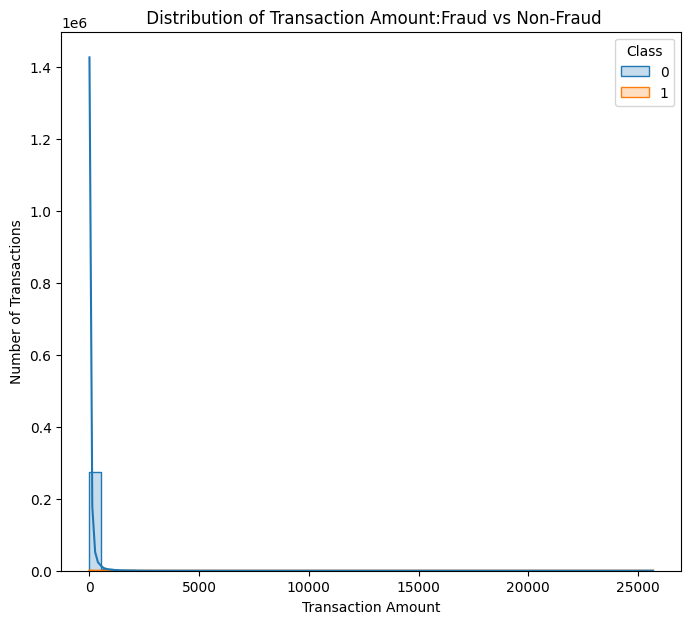

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,7))
sns.histplot(
   data=df,
x="Amount",
hue="Class",
bins=50,kde=True,
element="step")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title(" Distribution of Transaction Amount:Fraud vs Non-Fraud")

plt.show()

<h3 style="color:skyblue;">Time-of-Day analysis</h3>


We analyse transactions based on the time of day and compare normal and fraudulent transactions.

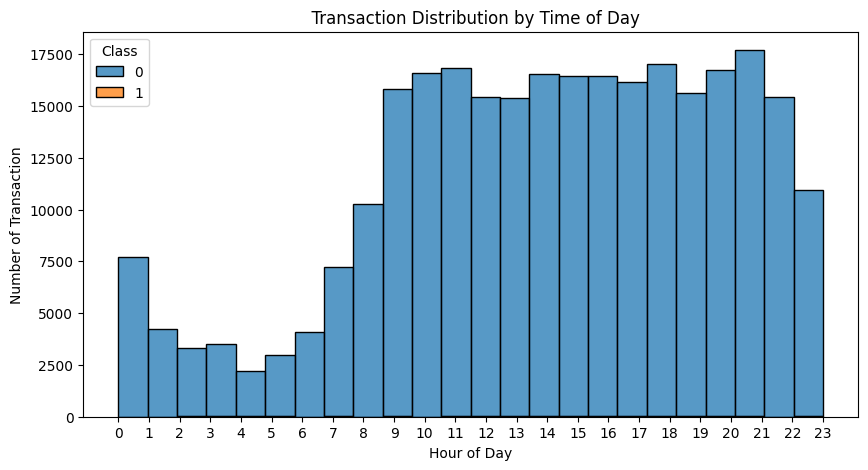

In [41]:

df["Hour"]=(df["Time"]//3600)%24
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x="Hour",
    hue="Class",bins=24,
    multiple="stack",
    
)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transaction")
plt.title("  Transaction Distribution by Time of Day")
plt.xticks(range(0,24))
plt.show()

<h3 style="color:skyblue;">Step 3: </h3>

The dataset is highly imbalanced because fraudulent transactions are very few compared to normal transactions.A model can get high accuracy by predicting most transactions as normal while missing many fraud cases.Therefore,accuracy alone is not a suitable metric for fraud detection.Precision,F1-score and AUC_ROC are more useful for evaluating the model.

In [47]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X=df.drop(["Class"],axis=1)
y=df["Class"]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Before SMOTE:")
print(y_train.value_counts())

smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
print("\nTraining data shape before SMOTE:",X_train.shape)
print("\nTraining data shape after SMOTE:",X_train_smote.shape)
print("Testing data shape:",X_test.shape)

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Training data shape before SMOTE: (227845, 31)

Training data shape after SMOTE: (454902, 31)
Testing data shape: (56962, 31)


In [46]:
from sklearn.model_selection import train_test_split

X=df.drop("Class",axis=1)
y=df["Class"]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training set::")
print(y_train.value_counts())
print("Testing set::")
print(y_test.value_counts())



Training set::
Class
0    227451
1       394
Name: count, dtype: int64
Testing set::
Class
0    56864
1       98
Name: count, dtype: int64


<h3 style="color:skyblue;">Step 4:Train 2  Model</h3>

We train two machine learning models,logistic regression and random forest,to detect fraudelent transactions.



In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
# Logistic Regression
logistic_model=LogisticRegression(max_iter=2000,random_state=42)
logistic_model.fit(X_train_smote,y_train_smote)
#Decision tree
decision_tree_model=DecisionTreeClassifier(
    
    random_state=42
   
)
decision_tree_model.fit(X_train_smote,y_train_smote)
print("Both models runned successfully")


C:\Users\jeevi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Both models runned successfully


<h3 style="color:skyblue;">Step 5:Evaluate The Model</h3>

we evaluate both models usinf precision,F1-score and AUC-ROC to measure their fraud detection performance.

In [49]:
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score,classification_report,roc_curve
#Predictions
y_pred_lr=logistic_model.predict(X_test)
y_prob_lr=logistic_model.predict_proba(X_test)[:,1]
y_pred_dt=decision_tree_model.predict(X_test)
y_prob_dt=decision_tree_model.predict_proba(X_test)[:,1]

print("Logistic Regression")
print("Precision:",precision_score(y_test,y_pred_lr))
print("Recall:",recall_score(y_test,y_pred_lr))
print("F1-Score:",f1_score(y_test,y_pred_lr))
print("AUC-ROC:",roc_auc_score(y_test,y_prob_lr))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_lr))
print("Decision Tree")
print("Precision:",precision_score(y_test,y_pred_dt))
print("Recall:",recall_score(y_test,y_pred_dt))
print("F1-Score:",f1_score(y_test,y_pred_dt))
print("AUC-ROC:",roc_auc_score(y_test,y_prob_dt))

print("Classification report:")
print(classification_report(y_test,y_pred_dt))


Logistic Regression
Precision: 0.11013767209011265
Recall: 0.8979591836734694
F1-Score: 0.19620958751393533
AUC-ROC: 0.9735464423529683

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.90      0.20        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.59     56962
weighted avg       1.00      0.99      0.99     56962

Decision Tree
Precision: 0.42391304347826086
Recall: 0.7959183673469388
F1-Score: 0.5531914893617021
AUC-ROC: 0.897027135277296
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.80      0.55        98

    accuracy                           1.00     56962
   macro avg       0.71      0.90      0.78     56962
weighted avg       1.00      1.00      1.00     56962



<h3 style="color:skyblue;">Step 6:AUC-ROC Curve</h3>
The ROC curve shows the relationship between the True positive rate and False positive rate at different classification thresholds.AUC summarizes the models ability to distinguish fraudulent transaction from non-fradulent transactions.

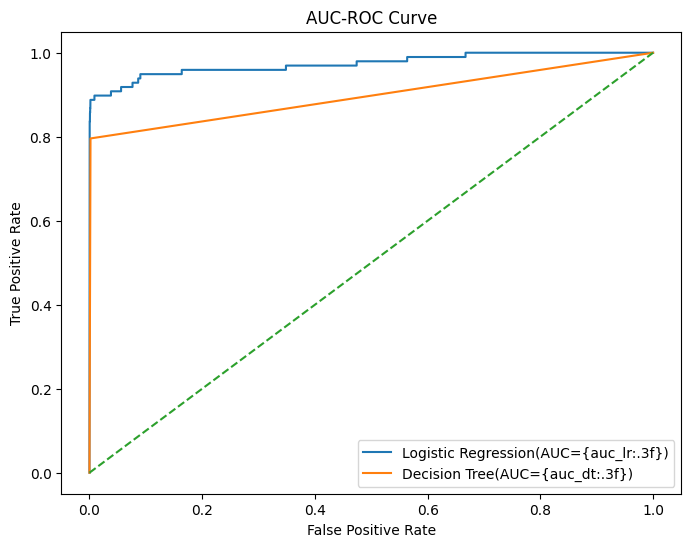

In [51]:

fpr_lr,tpr_lr,_=roc_curve(y_test,y_prob_lr)
fpr_dt,tpr_dt,_=roc_curve(y_test,y_prob_dt)
auc_lr=roc_auc_score(y_test,y_prob_lr)
auc_dt=roc_auc_score(y_test,y_prob_dt)
plt.figure(figsize=(8,6))
plt.plot(fpr_lr,tpr_lr,label="Logistic Regression(AUC={auc_lr:.3f})")
plt.plot(fpr_dt,tpr_dt,label="Decision Tree(AUC={auc_dt:.3f})")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()
plt.show()



<h3 style="color:skyblue;">Step 7 :Recall vs Precision</h3>

Recall measures the proportion of actual fraudulent transactions that are correctly identified by the model. High recall is important in fraud detection because missing a fraudulent transaction can result in financial loss.

Precision measures the proportion of transactions predicted as fraudulent that are actually fraudulent. High precision is also important because too many false fraud alerts can inconvenience legitimate customers.

For fraud detection, recall is often given high importance when the cost of missing fraud is greater than the cost of investigating false alerts. However, maximizing recall alone can produce more false positives and reduce precision.

Therefore, a practical fraud detection system should balance Recall and Precision according to the business cost of false negatives and false positives. The F1-Score can also be used to evaluate the balance between Precision and Recall.

<h3 style="color:skyblue;">Step 8:Feature Importance/Coefficient Analysis</h3>


Random Forest feature importance was used to identify the features that contributed most to the model's predictions. Features with higher importance values had a greater influence on the model's classification decisions.

The top features can provide useful information about which transaction characteristics are associated with the model's fraud predictions. Feature importance shows the model's predictive contribution of a feature, but it does not by itself prove that a feature causes fraud.

   Feature  Importance
14     V14    0.807629
4       V4    0.048534
17     V17    0.026574
1       V1    0.015533
12     V12    0.009493
13     V13    0.008318
3       V3    0.008010
30    Hour    0.006155
21     V21    0.005751
15     V15    0.005638


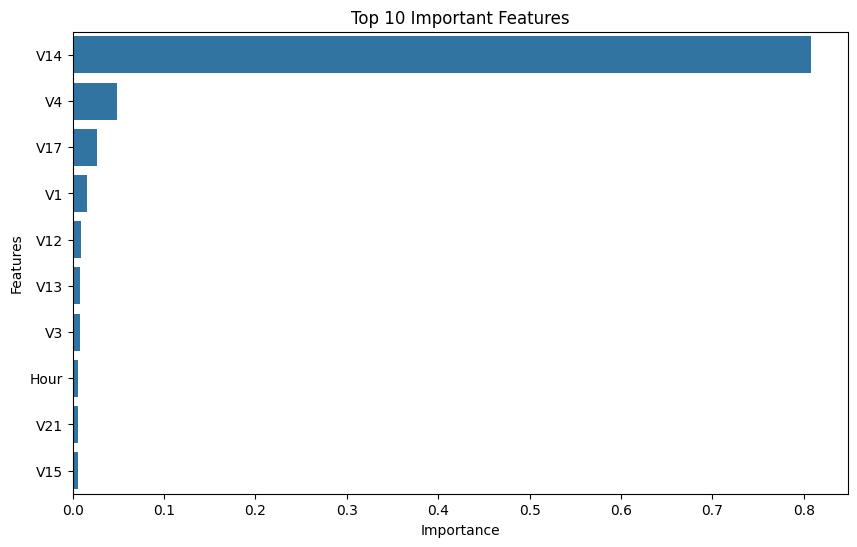

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
feature_importance=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":decision_tree_model.feature_importances_
})
feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
print(feature_importance.head(10))
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
x="Importance",
y="Feature"
)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

<h3 style="color:skyblue;">Step 9:Scalability:1 Million Transactions per Hour</h3>

A real-world fraud detection system may need to process around 1 million transactions per hour, which is approximately 278 transactions per second.

To handle this volume, the model could be deployed as a scalable real-time prediction service. Transactions could be processed through distributed streaming systems such as Apache Kafka, allowing multiple processing instances to handle transactions in parallel.

The trained machine learning model could be deployed using a lightweight API service such as FastAPI. Multiple instances of the prediction service could be deployed behind a load balancer to distribute incoming requests.

For better performance, the system could use:
- Parallel and distributed processing
- Multiple model-serving instances
- Batch processing where real-time prediction is not required
- Fast databases and caching
- Monitoring for model performance and data drift
- Periodic retraining using newly collected transaction data

The model should also be optimized so that fraud predictions can be generated with low latency. This architecture would allow the fraud detection system to scale as transaction volume increases.